# <font color='#3d59c6'> MD004 SESIÓN CLASIFICADOR NAIVE BAYES </font>

**MODELO**: Naive Bayes para detección de spam

 <font color='#134F5C'> Naive Bayes (NB) es un algoritmo de clasificación que usa datos de eventos pasadoos para calcuar la probabilidad de eventos futuros. Típicamente se emplea en problemas en los que contamos con una gran candidad de atributos y todos deben considerarse simultáneamente.</font>

**DATA**: En este ejemplo utilizaremos el dataset: **20230202 Subject vs Spam.csv** con el cual crearemos el modelo y lo validaremos. Por otro lado tendremos un segundo fichero (**20230202 Subject Ecommerce**) con una bateria de subjects que necesitaremos cribar respecto a si son válidos o no.

**OBJETIVO:** Vamos a crear un modelo que nos permita identificar la clasificación de un email en base al subject, indicando si es spam o por contra es ham y por lo tanto podrá llegar a la bandeja de entrada.
Una vez generado este modelo vamos a validar una batería de subjects preparados para diferentes campañas de eMailing y observaremos como quedan clasificados y hay alguno que se deba redefinir.

El objetivo es calcular eventos mutuamente incluyentes para el mismo test. Por atendiendo al ejemplo de SPAM:

- Spam e Inbox son categorías mutuamente excluyentes

Depende de la probabilidad condicionada de los 2 eventos. En el ejemplo que estamos tratando imaginemos que P(Ahora) es independiente de P(Spam): En este caso sería fácil de calcular P(Ahora ∩ Spam) como P(Ahora) x P(Spam). La realidad es que P(Spam) y P(Ahora) están íntimamente relacionados. NB será la herramienta que utilizaremos para calcular las probabilidades condicionadas a posteriori:


$${P(Spam|Ahora)} =  P(Ahora|Spam) * P(Spam) / P(Ahora) $$

![image.png](attachment:image.png)

**PASOS:**

0. Plantear estrategia
1. Trabajar fichero de texto: transformación del dataset
2. Generación del modelo
3. Validar modelo
4. Estimar cuantos de los subjects del fichero campañas eMailing son aptos para ser usados

**Fuente datos:** Recopilación de emails de diferentes cuentas

## <font color='#3d59c6'>  CARGA DE PACKAGES </font>

In [1]:
install.packages('xml2')

Installing package into ‘/home/chriss/R/x86_64-pc-linux-gnu-library/4.1’
(as ‘lib’ is unspecified)



In [2]:
install.packages('slam')
install.packages('tm')
install.packages('SnowballC')
install.packages('gmodels')
install.packages('wordcloud')
install.packages("e1071")
install.packages("caret")

Installing package into ‘/home/chriss/R/x86_64-pc-linux-gnu-library/4.1’
(as ‘lib’ is unspecified)



Installing package into ‘/home/chriss/R/x86_64-pc-linux-gnu-library/4.1’
(as ‘lib’ is unspecified)

Installing package into ‘/home/chriss/R/x86_64-pc-linux-gnu-library/4.1’
(as ‘lib’ is unspecified)

Installing package into ‘/home/chriss/R/x86_64-pc-linux-gnu-library/4.1’
(as ‘lib’ is unspecified)

Installing package into ‘/home/chriss/R/x86_64-pc-linux-gnu-library/4.1’
(as ‘lib’ is unspecified)

Installing package into ‘/home/chriss/R/x86_64-pc-linux-gnu-library/4.1’
(as ‘lib’ is unspecified)

Installing package into ‘/home/chriss/R/x86_64-pc-linux-gnu-library/4.1’
(as ‘lib’ is unspecified)



In [3]:
library(e1071)
library(caret)
library(tm)
library(SnowballC)
library(wordcloud)
library(gmodels)
library(wordcloud)

Loading required package: ggplot2


Attaching package: ‘ggplot2’


The following object is masked from ‘package:e1071’:

    element


Loading required package: lattice

Loading required package: NLP


Attaching package: ‘NLP’


The following object is masked from ‘package:ggplot2’:

    annotate


Loading required package: RColorBrewer



## <font color='#3d59c6'>  CARGA DE DATOS </font>

- Variable dependiente (target) **type** (nos indica si google lo clasifica como spam o lo ha dejado llegar a la bandeja de entrada (inbox)
- Variables explicativas o predictoras:

    - **subject**

In [4]:
data_subject = read.csv(file='../data/20230202 Subject vs Spam.csv', header=TRUE, sep=';', dec=',')
head(data_subject)#de forma predefinida retorna las primeras 6 observations
tail(data_subject)#de forma predefinida retorna las últimas 6 observations

,type,subject
,<chr>,<chr>
1,spam,Tres cupones descuento para ti
2,spam,"¡Sorpresa! Shiseido ya está disponible, ¡aprovéchalo!"
3,spam,¡Oferta online! Precio fijo 24h sin subidas en luz y sin permanencia
4,inbox,4 semana septiembre plan de redes
5,inbox,Categorías contenido y fuentes 2
6,spam,Estamos de REBAJAS ⚡ ¡Solo 72 horas!


,type,subject
,<chr>,<chr>
601,spam,Tu plan Premium tiene un 60% de descuento
602,inbox,La inteligencia artificial será clave en la transformación de los servicios financieros
603,spam,"asociate a Emergencias Salud, 70% de descuento los 3 primeros meses + 30% de descuento los siguientes 4 meses"
604,inbox,Stage d'​innovation: DATOS + IA
605,inbox,12 valoracion y riesgo crediticio en colombia
606,spam,Las rebajas. Acaban. Hoy


## <font color='#3d59c6'>  EXPLORACION </font>

In [5]:
str(data_subject)

'data.frame':	606 obs. of  2 variables:
 $ type   : chr  "spam" "spam" "spam" "inbox" ...
 $ subject: chr  "Tres cupones descuento para ti" "¡Sorpresa! Shiseido ya está disponible, ¡aprovéchalo!" "¡Oferta online! Precio fijo 24h sin subidas en luz y sin permanencia" "4 semana septiembre plan de redes" ...


In [6]:
install.packages("dplyr")
library(dplyr)

Installing package into ‘/home/chriss/R/x86_64-pc-linux-gnu-library/4.1’
(as ‘lib’ is unspecified)




Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [7]:
install.packages("syuzhet")

Installing package into ‘/home/chriss/R/x86_64-pc-linux-gnu-library/4.1’
(as ‘lib’ is unspecified)



In [8]:
install.packages("textdata")

Installing package into ‘/home/chriss/R/x86_64-pc-linux-gnu-library/4.1’
(as ‘lib’ is unspecified)



In [9]:
library(dplyr)
library(textdata)
library(syuzhet)

In [10]:
install.packages("tidytext")
library(tidytext)


Installing package into ‘/home/chriss/R/x86_64-pc-linux-gnu-library/4.1’
(as ‘lib’ is unspecified)



In [11]:
data_subject <- data_subject %>%
  mutate(review_id = row_number(),  # ID para cada reseña
         polarity = get_sentiment(subject, method = "syuzhet"))

         # 2. CREAR tokenized_reviews (esto faltaba)
tokenized_reviews <- data_subject %>%
  select(review_id, subject, type, polarity) %>%
  unnest_tokens(word, subject)

# Verificar que se creó
head(tokenized_reviews)

,review_id,type,polarity,word
,<int>,<chr>,<dbl>,<chr>
1,1,spam,0,tres
2,1,spam,0,cupones
3,1,spam,0,descuento
4,1,spam,0,para
5,1,spam,0,ti
6,2,spam,0,sorpresa


In [12]:
# Agrupamos por 'package_name' y calculamos la proporción de polaridad
proporciones <- data_subject %>%
  group_by(subject) %>%
  summarise(
    proporcion_spam = mean(type == "spam") * 100,
    proporcion_inbox = mean(type == "inbox") * 100
  )
# Mostrar el resultado
print(proporciones)

# A tibble: 604 × 3
   subject                                      proporcion_spam proporcion_inbox
   <chr>                                                  <dbl>            <dbl>
 1 #SemanaWeb 💻 Exclusiva Online                           100                0
 2 'Tokenise Europe 2025', un llamamiento a di…               0              100
 3 -10% EXTRA en TODO 💥 Aprovéchalo en las Ofe…             100                0
 4 -12% o -6% dto en TODO* 🚨 ÚLTIMO DÍA 🚨                 100                0
 5 -20% EXTRA en rebajas de hasta -70%                      100                0
 6 -25% LOVE YOURSELF                                       100                0
 7 -25% ULTIMO DIA                                          100                0
 8 -25% 🔥 ¡Empieza por lo irresistible!                    100                0
 9 -30% -35% -40% 🧨¡Únete, gana y celebra!                 100                0
10 1 empleo nuevo para «Científico de datos»                  0              100
# ℹ 594 more 

In [13]:
# Unir las palabras tokenizadas con la polaridad y calcular el promedio

words_with_polarity <- tokenized_reviews %>%
  group_by(word) %>%
  summarise(
    avg_polarity = mean(polarity),  # promedio de polaridad de reseñas donde aparece la palabra
    n_reviews = n()
  ) %>%
  arrange(desc(avg_polarity))
head(words_with_polarity)


word,avg_polarity,n_reviews
<chr>,<dbl>,<int>
opportunities,1.5,1
r,1.5,1
talent,1.5,1
bcp,1.2,1
learning,1.2,1
machine,1.2,1


In [14]:
# Filtrar palabras que aparecen al menos 10 veces
relevant_words <- words_with_polarity %>%
  filter(n_reviews > 10)

# Eliminar las stop words (palabras comunes)
data("stop_words")
cleaned_words <- relevant_words %>%
  anti_join(stop_words, by = "word")

head(relevant_words)

word,avg_polarity,n_reviews
<chr>,<dbl>,<int>
plan,0.12916667,12
hoy,0.10000000,12
datos,0.09166667,12
70,0.08750000,12
no,0.08666667,15
2023,0.08461538,13


[1] "plan"  "hoy"   "datos" "70"    "no"    "2023"

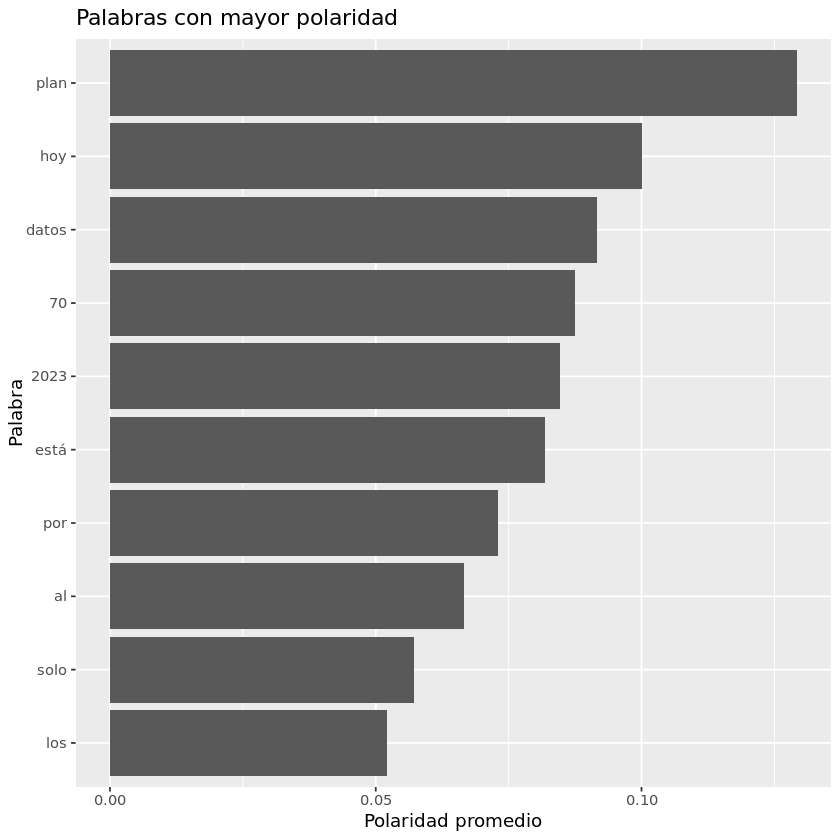

In [15]:
# Graficar las 10 palabras con mayor polaridad
ggplot(cleaned_words %>% top_n(10, avg_polarity), aes(x = reorder(word, avg_polarity), y = avg_polarity)) +
  geom_col() +
  coord_flip() +
  labs(title = "Palabras con mayor polaridad", x = "Palabra", y = "Polaridad promedio")

head(relevant_words$word)

Warning message in tm_map.SimpleCorpus(corpus, tm::removePunctuation):
“transformation drops documents”


Warning message in tm_map.SimpleCorpus(corpus, function(x) tm::removeWords(x, tm::stopwords())):
“transformation drops documents”


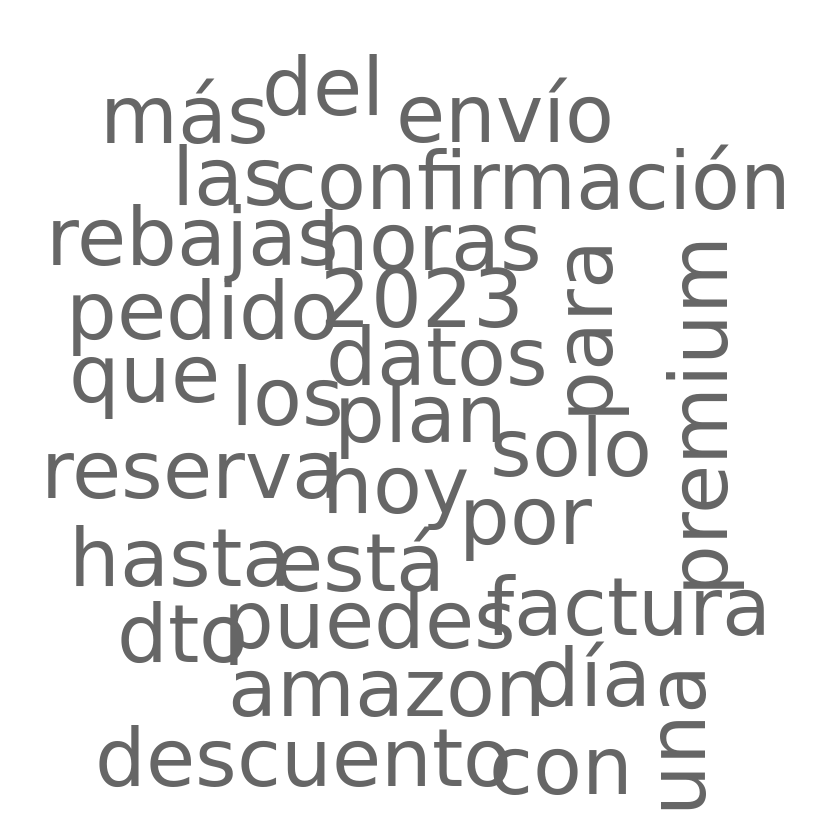

In [16]:
# Crear la paleta de colores
#pal <- brewer.pal(8, "Dark2")

# Crear la nube de palabras basada en la polaridad promedio
#wordcloud(
#  words = cleaned_words$word,  # Las palabras a mostrar
  #freq = relevant_words$avg_polarity,  # Usar la polaridad promedio como frecuencia
#  max.words = 30,  # Número máximo de palabras que se mostrarán
#  random.order = F,  # Mostrar las palabras más frecuentes en el centro
#  colors = brewer.pal(name = "Dark2", n = 8)  # Paleta de colores
#)
wordcloud(relevant_words$word, max.words = 30, random.order = F, colors = brewer.pal(name = "Dark2", n = 8))

In [17]:
# Crear un Corpus con las reseñas
corpus <- Corpus(VectorSource(data_subject$subject))

# Preprocesamiento del texto con tm_map():
# Convertir a minúsculas, eliminar puntuación, números y palabras comunes (stop words)
corpus <- tm_map(corpus, content_transformer(tolower))  # Convertir a minúsculas
corpus <- tm_map(corpus, removePunctuation)  # Eliminar puntuación
corpus <- tm_map(corpus, removeNumbers)  # Eliminar números
corpus <- tm_map(corpus, removeWords, stopwords("en"))  # Eliminar stop words en inglés

# Convertir el corpus en un dataframe de palabras
review_clean <- data.frame(text = sapply(corpus, as.character), stringsAsFactors = FALSE)

Warning message in tm_map.SimpleCorpus(corpus, content_transformer(tolower)):
“transformation drops documents”
Warning message in tm_map.SimpleCorpus(corpus, removePunctuation):
“transformation drops documents”
Warning message in tm_map.SimpleCorpus(corpus, removeNumbers):
“transformation drops documents”
Warning message in tm_map.SimpleCorpus(corpus, removeWords, stopwords("en")):
“transformation drops documents”


In [18]:
head(review_clean)

,text
,<chr>
1,tres cupones descuento para ti
2,¡sorpresa shiseido ya está disponible ¡aprovéchalo
3,¡oferta online precio fijo h sin subidas en luz y sin permanencia
4,semana septiembre plan de redes
5,categorías contenido y fuentes
6,estamos de rebajas ⚡ ¡solo horas


In [19]:
review_clean <- review_clean %>%
  mutate(review_id = row_number(),  # ID para cada reseña
         polarity = get_sentiment(text, method = "syuzhet"))

In [20]:
# PASO 2: Tokenizar las palabras de cada reseña
tokenized_reviews1 <- review_clean %>%
  select( text,polarity) %>%
  unnest_tokens(word, text)

head(tokenized_reviews1)

,polarity,word
,<dbl>,<chr>
1,0,tres
2,0,cupones
3,0,descuento
4,0,para
5,0,ti
6,0,sorpresa


In [21]:
# Unir las palabras tokenizadas con la polaridad y calcular el promedio

words_with_polarity1 <- tokenized_reviews1 %>%
  group_by(word) %>%
  summarise(
    avg_polarity = mean(polarity),  # promedio de polaridad de reseñas donde aparece la palabra
    n_reviews = n()
  ) %>%
  arrange(desc(avg_polarity))
head(words_with_polarity1)


word,avg_polarity,n_reviews
<chr>,<dbl>,<int>
opportunities,1.5,1
r,1.5,1
talent,1.5,1
bcp,1.2,1
learning,1.2,1
machine,1.2,1


In [22]:
# Filtrar palabras que aparecen al menos 10 veces
relevant_words1 <- words_with_polarity1 %>%
  filter(n_reviews > 10)

# Eliminar las stop words (palabras comunes)
data("stop_words")
cleaned_words1 <- relevant_words1 %>%
  anti_join(stop_words, by = "word")

head(relevant_words1)

word,avg_polarity,n_reviews
<chr>,<dbl>,<int>
plan,0.12916667,12
hoy,0.10000000,12
datos,0.09166667,12
está,0.08181818,22
por,0.07307692,26
al,0.06666667,15


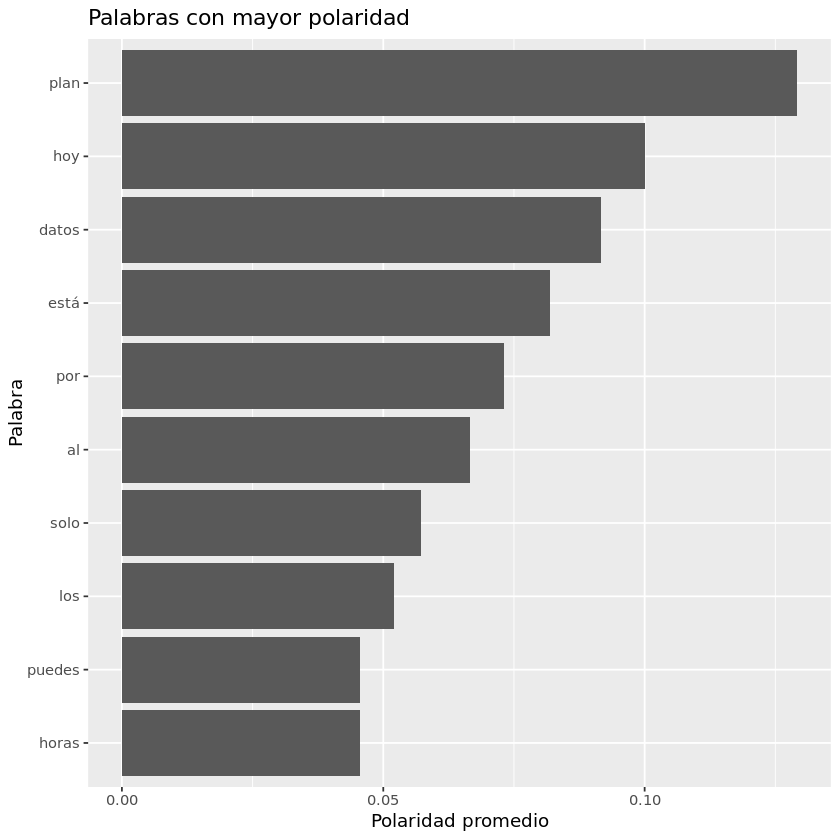

In [23]:
# Graficar las 10 palabras con mayor polaridad promedio
ggplot(relevant_words1 %>% top_n(10, avg_polarity), aes(x = reorder(word, avg_polarity), y = avg_polarity)) +
  geom_col() +
  coord_flip() +
  labs(title = "Palabras con mayor polaridad", x = "Palabra", y = "Polaridad promedio")

Warning message in tm_map.SimpleCorpus(corpus, tm::removePunctuation):
“transformation drops documents”
Warning message in tm_map.SimpleCorpus(corpus, function(x) tm::removeWords(x, tm::stopwords())):
“transformation drops documents”


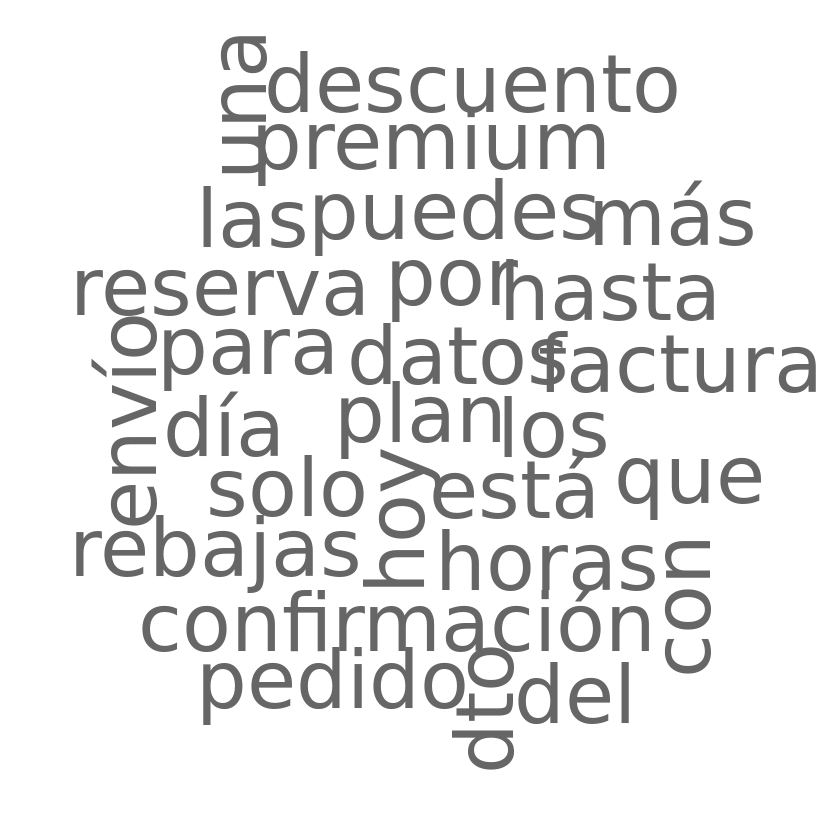

In [24]:
# Crear la paleta de colores
pal <- brewer.pal(8, "Dark2")

# Crear la nube de palabras basada en la polaridad promedio
wordcloud(
  words = relevant_words1$word,  # Las palabras a mostrar
  #freq = relevant_words$avg_polarity,  # Usar la polaridad promedio como frecuencia
  max.words = 30,  # Número máximo de palabras que se mostrarán
  random.order = F,  # Mostrar las palabras más frecuentes en el centro
  colors = brewer.pal(name = "Dark2", n = 8)  # Paleta de colores
)

#wordcloud(data_corpus_clean, max.words = 30, random.order = F, colors = brewer.pal(name = "Dark2", n = 8))




---







In [25]:
# Calculate the proportions
proportions <- prop.table(table(tokenized_reviews1$word, tokenized_reviews1$polarity)) * 100

# Round the proportions to 1 decimal place
proportions <- round(proportions, digits = 1)

# Display the results
print(proportions)

                             
                              -0.75 -0.65 -0.6 -0.5 -0.4 -0.25 -0.15   0 0.1
  ª                             0.0   0.0  0.0  0.0  0.0   0.0   0.0 0.2 0.0
  à                             0.0   0.0  0.0  0.0  0.0   0.0   0.0 0.1 0.0
  abrigos                       0.0   0.0  0.0  0.0  0.0   0.0   0.0 0.0 0.0
  acaba                         0.0   0.0  0.0  0.0  0.0   0.0   0.0 0.0 0.0
  acabado                       0.0   0.0  0.0  0.0  0.0   0.0   0.0 0.0 0.0
  acaban                        0.0   0.0  0.0  0.0  0.0   0.0   0.0 0.0 0.0
  académica                     0.0   0.0  0.0  0.0  0.0   0.0   0.0 0.0 0.0
  acaso                         0.0   0.0  0.0  0.0  0.0   0.0   0.0 0.0 0.0
  acceso                        0.0   0.0  0.0  0.0  0.0   0.0   0.0 0.0 0.0
  acción                        0.0   0.0  0.0  0.0  0.0   0.0   0.0 0.0 0.0
  acciones                      0.0   0.0  0.0  0.0  0.0   0.0   0.0 0.0 0.0
  account                       0.0   0.0  0.0

In [26]:
# Proporción de clases
prop.table(table(tokenized_reviews1$word, tokenized_reviews1$polarity)*100)

# Crear la tabla de contingencia
tabla_polaridad <- table(tokenized_reviews1$word, tokenized_reviews1$polarity)

# Realizar el test de Chi-cuadrado
chi_test <- chisq.test(tabla_polaridad)

# Ver los resultados
print(chi_test)

                             
                                     -0.75        -0.65         -0.6
  ª                           0.0000000000 0.0000000000 0.0000000000
  à                           0.0000000000 0.0000000000 0.0000000000
  abrigos                     0.0000000000 0.0000000000 0.0000000000
  acaba                       0.0000000000 0.0000000000 0.0000000000
  acabado                     0.0000000000 0.0000000000 0.0000000000
  acaban                      0.0000000000 0.0000000000 0.0000000000
  académica                   0.0000000000 0.0000000000 0.0000000000
  acaso                       0.0000000000 0.0000000000 0.0000000000
  acceso                      0.0000000000 0.0000000000 0.0000000000
  acción                      0.0000000000 0.0000000000 0.0000000000
  acciones                    0.0000000000 0.0000000000 0.0000000000
  account                     0.0000000000 0.0000000000 0.0000000000
  aceptadas                   0.0000000000 0.0000000000 0.0000000000
  ac

Warning message in chisq.test(tabla_polaridad):
“Chi-squared approximation may be incorrect”



	Pearson's Chi-squared test

data:  tabla_polaridad
X-squared = 39761, df = 29963, p-value < 2.2e-16



In [27]:
# Instalar y cargar el paquete necesario
install.packages("tidytext")
library(tidytext)
#library(dplyr)

Installing package into ‘/home/chriss/R/x86_64-pc-linux-gnu-library/4.1’
(as ‘lib’ is unspecified)



In [28]:
tokenized_reviews1 <- tokenized_reviews1 %>%
  mutate(type = case_when(
    polarity >  0.1  ~ "positivo",
    polarity < -0.1  ~ "negativo",
    TRUE             ~ "neutro"
  ))

# Convertimos a factor
#tokenized_reviews1$type <- factor(tokenized_reviews1$polarity)

# Ver niveles del factor
levels(tokenized_reviews1$type)

NULL

In [29]:
tokenized_reviews1

polarity,word,type
<dbl>,<chr>,<chr>
0.00,tres,neutro
0.00,cupones,neutro
0.00,descuento,neutro
0.00,para,neutro
0.00,ti,neutro
0.00,sorpresa,neutro
0.00,shiseido,neutro
0.00,ya,neutro
0.00,está,neutro


In [30]:

# Filtrar palabras positivas, contar frecuencia, ordenar ascendente
frecuencia_positivas <- tokenized_reviews1 %>%
  filter(type == 'positivo') %>%
  count(word, sort = FALSE) %>%
  arrange(n)  # orden ascendente

# Filtrar palabras negativas, contar frecuencia, ordenar ascendente
frecuencia_negativas <- tokenized_reviews1 %>%
  filter(type == 'negativo') %>%
  count(word, sort = FALSE) %>%
  arrange(n)  # orden ascendente

# Mostrar las palabras menos frecuentes
print(head(frecuencia_positivas))
print(head(frecuencia_negativas))

      word n
1  account 1
2    agile 1
3 airsalon 1
4 allinone 1
5   alumni 1
6   amazon 1
    word n
1  adiós 1
2 agiles 1
3  ahora 1
4 ahorra 1
5    air 1
6     al 1


## <font color='#3d59c6'>  TRANSFORMACIÓN Y LIMPIEZA DEL DATASET </font>

Nuestro objetivo en este punto será crear un mapa de palabras, analizar qué palabras se repiten más, etc
Lo primero que haremos será aplicar la función VectorSource() esto nos tratará cada fila como si fuese un documento. Luego con VCorpus() alamcenaremos esta colección de "datos" (documentos).

**VENTAJAS**

- A nivel computacional los datos se guardan en la memoria, por lo que computacionalmente es más eficiente
- El tipo de almacenamiento corpus tiene funciones que nos permiten manipular textos de una forma eficiente con funciones predefinidas

In [31]:
data_corpus = VCorpus(VectorSource(data_subject$subject),readerControl = list(language = 'es'))
print(data_corpus)

<<VCorpus>>
Metadata:  corpus specific: 0, document level (indexed): 0
Content:  documents: 606


La transformación del texto se realiza utilizando la función tm_map() que nos va a permitir eliminar signos, acentos, espacios,...

In [32]:
# Esta transformación cambia todas las mayúsculas a minúsculas
data_corpus_clean = tm_map(data_corpus, content_transformer(tolower))
# Visualización de la instancia antes y después de la transformación
print(lapply(data_corpus[[1]][1], as.character))
print(lapply(data_corpus_clean[[1]][1], as.character))

$content
[1] "Tres cupones descuento para ti"

$content
[1] "tres cupones descuento para ti"



In [33]:
# Esta transformación retira números y palabras conectoras de lenguaje y a texto plano
data_corpus_clean = tm_map(data_corpus_clean, removeNumbers)
data_corpus_clean = tm_map(data_corpus_clean, removeWords, stopwords("spanish"))

# Visualización de la instancia antes y después de la transformación
print(lapply(data_corpus[[1]][1], as.character))
print(lapply(data_corpus_clean[[1]][1], as.character))

$content
[1] "Tres cupones descuento para ti"

$content
[1] "tres cupones descuento  "



In [34]:
data_corpus_clean <- tm_map(data_corpus_clean, removePunctuation)
print(lapply(data_corpus[[1]][1], as.character))
print(lapply(data_corpus_clean[[1]][1], as.character))

$content
[1] "Tres cupones descuento para ti"

$content
[1] "tres cupones descuento  "



Esta función no elimina los signos “¡” y “¿”, creamos una función que nos ayude con la limpieza

In [35]:
# sustituye puntuaciones por espacios
replacePunctuation = function(x) {gsub('[[:punct:]]', ' ', x)}

data_corpus_clean = tm_map(data_corpus_clean, replacePunctuation)
# Visualización de la instancia antes y después de la transformación
print(lapply(data_corpus[[1]][1], as.character))
print(lapply(data_corpus_clean[[1]][1], as.character))

$content
[1] "Tres cupones descuento para ti"

[[1]]
[1] "tres cupones descuento  "



In [36]:
removeAccents = function(x) chartr('àáèéìíòóùú', 'aaeeiioouu', x)
data_corpus_clean = tm_map(data_corpus_clean, removeAccents)
print(lapply(data_corpus[[1]][1], as.character))
print(lapply(data_corpus_clean[[1]][1], as.character))

$content
[1] "Tres cupones descuento para ti"



[[1]]
[1] "tres cupones descuento  "



In [37]:
data_corpus_clean = tm_map(data_corpus_clean, stripWhitespace)
# Visualización de la instancia antes y después de la transformación
print(lapply(data_corpus[[1]][1], as.character))
print(lapply(data_corpus_clean[[1]][1], as.character))

$content
[1] "Tres cupones descuento para ti"

[[1]]
[1] "tres cupones descuento "



A través de tm_map podemos invocar a la función **stemDocument** con el objetivo de unificar aquellos términos que aportan la misma información (tienen la misma base semántica)

In [38]:
data_corpus_clean = tm_map(data_corpus_clean, stemDocument)
print(lapply(data_corpus[[1]][1], as.character))
print(lapply(data_corpus_clean[[1]][1], as.character))

$content
[1] "Tres cupones descuento para ti"

[[1]]
[1] "tres cupon descuento"



In [39]:
# especificando un vector de palabras comunes a ser eliminadas
data_corpus_clean = tm_map(data_corpus_clean, removeWords, c('los', 'las','si'))

In [40]:
data_corpus_clean = tm_map(data_corpus_clean, PlainTextDocument)

In [41]:
for (i in (1:5))
{
    print(paste0("subject number ", i))
    print(lapply(data_corpus[[i]][1], as.character))
    print(lapply(data_corpus_clean[[i]][1], as.character))
}

[1] "subject number 1"
$content
[1] "Tres cupones descuento para ti"

$content
[1] "tres cupon descuento"

[1] "subject number 2"
$content
[1] "¡Sorpresa! Shiseido ya está disponible, ¡aprovéchalo!"

$content
[1] "sorpresa shiseido dispon aprovechalo"

[1] "subject number 3"
$content
[1] "¡Oferta online! Precio fijo 24h sin subidas en luz y sin permanencia"

$content
[1] "oferta onlin precio fijo h subida luz permanencia"

[1] "subject number 4"
$content
[1] "4 semana septiembre plan de redes"

$content
[1] "semana septiembr plan rede"

[1] "subject number 5"
$content
[1] "Categorías contenido y fuentes 2"

$content
[1] "categoria contenido fuent"



## <font color='#3d59c6'> LO MISMO PERO DECLARANDO UNA FUNCIÓN </font>

Se incluye la función stemDocument >> A través de tm_map podemos invocar a la función stemDocument con el objetivo de unificar aquellos términos que aportan la misma información (tienen la misma base semántica)

In [42]:
replacePunctuation = function(x) {gsub('[[:punct:]]', ' ', x)}
removeAccents = function(x) chartr('àáèéìíòóùú', 'aaeeiioouu', x)

clean_corpus = function(corpus){
               data_corpus_clean = tm_map(corpus, content_transformer(tolower))
               data_corpus_clean = tm_map(data_corpus_clean, removeNumbers)
               data_corpus_clean = tm_map(data_corpus_clean, removeWords, stopwords('spanish'))
               data_corpus_clean = tm_map(data_corpus_clean, removeWords, stopwords())
               data_corpus_clean = tm_map(data_corpus_clean, removePunctuation)
               data_corpus_clean = tm_map(data_corpus_clean, replacePunctuation)
               data_corpus_clean = tm_map(data_corpus_clean, removeAccents)
               data_corpus_clean = tm_map(data_corpus_clean, stripWhitespace)
               data_corpus_clean = tm_map(data_corpus_clean, removeWords, c('los', 'las','si','the'))
               #data_corpus_clean = tm_map(data_corpus_clean, stemDocument, 'spanish')
               data_corpus_clean = tm_map(data_corpus_clean, PlainTextDocument)
  return(data_corpus_clean)
}

In [43]:
data_corpus = VCorpus(VectorSource(data_subject$subject),readerControl = list(language = 'en'))
data_corpus_clean = clean_corpus(data_corpus)
print(lapply(data_corpus[[i]][1], as.character))
print(lapply(data_corpus_clean[[i]][1], as.character))

$content
[1] "Categorías contenido y fuentes 2"

$content
[1] "categorias contenido fuentes "



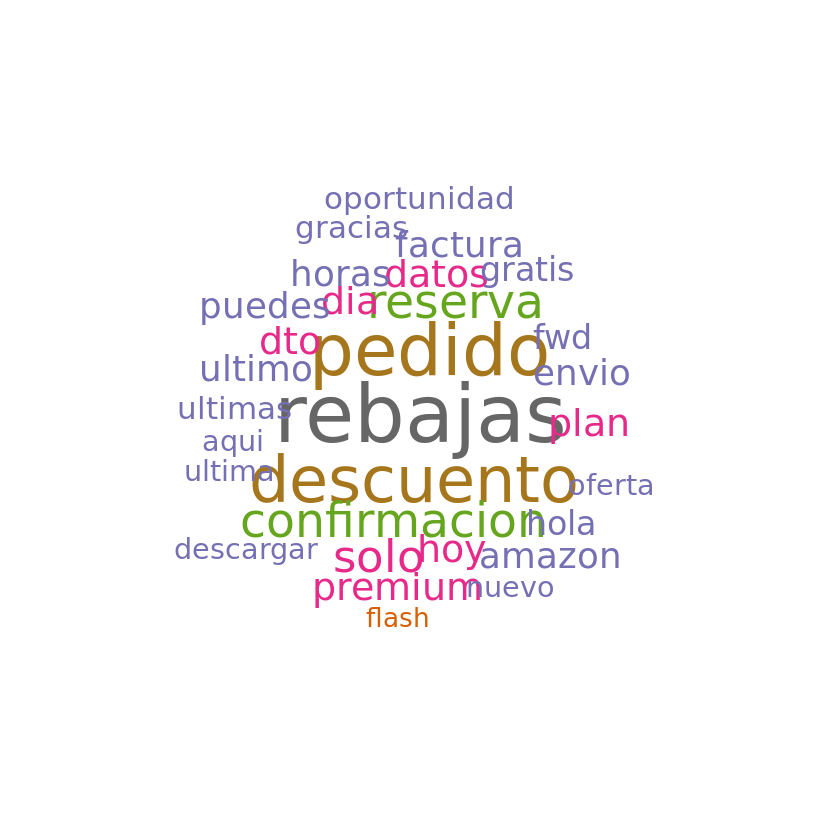

In [44]:
wordcloud(data_corpus_clean, max.words = 30, random.order = F, colors = brewer.pal(name = "Dark2", n = 8))

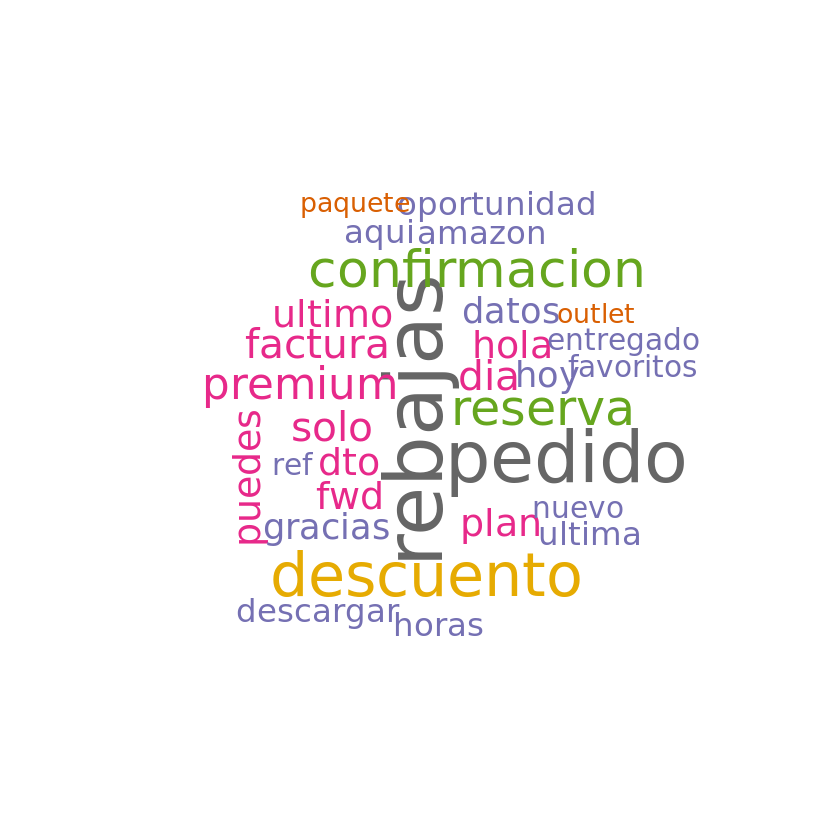

In [45]:

data_subject_spam <- subset(tokenized_reviews, polarity == 0)
data_corpus_spam = VCorpus(VectorSource(data_subject_spam$word),readerControl = list(language = 'es'))
data_corpus_clean_spam = clean_corpus(data_corpus_spam)

wordcloud(data_corpus_clean_spam, max.words = 30, random.order = F, colors = brewer.pal(name = "Dark2", n = 8))

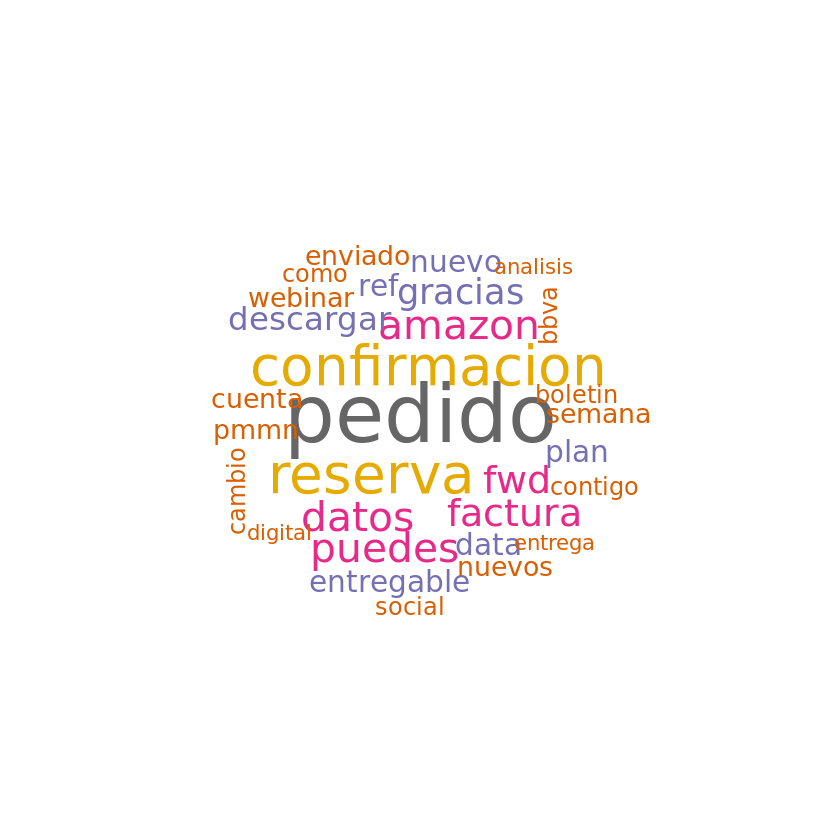

In [46]:
data_subject_ham <- subset(data_subject, data_subject$type =='inbox')
data_corpus_ham = VCorpus(VectorSource(data_subject_ham$subject),readerControl = list(language = 'es'))
data_corpus_clean_ham = clean_corpus(data_corpus_ham)

wordcloud(data_corpus_clean_ham, max.words = 30, random.order = F, colors = brewer.pal(name = "Dark2", n = 8))

## <font color='#3d59c6'>  SEPARACIÓN TRAIN & TEST </font>

Ahora transformaremos cada mensaje en palabras independientes para construir la estructura del análisis mediante una matrix compuesta por:

- Las columnas son la unión de todas las palabras definidas en el corpus
- Las filas son cada una de las instancias de los mensajes tal y como viene definido en el dataset entrante
- Los valores son el número de veces que se repite cada palabra en cada mensaje

La matriz generada estará compuesta principalmente de instancias de valor 0. La función *DocumentTermMatrix* nos ayudará a generar este conjunto.

In [47]:
dtm = DocumentTermMatrix(data_corpus_clean)
dtm

<<DocumentTermMatrix (documents: 606, terms: 1440)>>
Non-/sparse entries: 2402/870238
Sparsity           : 100%
Maximal term length: 27
Weighting          : term frequency (tf)

In [48]:
str(dtm)

List of 6
 $ i       : int [1:2402] 1 1 1 2 2 2 2 3 3 3 ...
 $ j       : int [1:2402] 356 391 1348 74 424 1230 1259 595 814 939 ...
 $ v       : num [1:2402] 1 1 1 1 1 1 1 1 1 1 ...
 $ nrow    : int 606
 $ ncol    : int 1440
 $ dimnames:List of 2
  ..$ Docs : chr [1:606] "character(0)" "character(0)" "character(0)" "character(0)" ...
  ..$ Terms: chr [1:1440] "abrigos" "acaba" "acabado" "acaban" ...
 - attr(*, "class")= chr [1:2] "DocumentTermMatrix" "simple_triplet_matrix"
 - attr(*, "weighting")= chr [1:2] "term frequency" "tf"


In [49]:
termFreq = colSums(as.matrix(dtm))
head(termFreq)
tabla_frec = data.frame(term = names(termFreq), freq = termFreq)
tabla_frec = tabla_frec[order(-tabla_frec[,2]),]
head(tabla_frec)

abrigos     acaba   acabado    acaban academica     acaso 
        1         1         1         1         1         1

,term,freq
,<chr>,<dbl>
rebajas,rebajas,30
pedido,pedido,26
descuento,descuento,23
confirmacion,confirmacion,16
reserva,reserva,16
solo,solo,15


In [ ]:
set.seed(555)

# Creamos el data partition de la función caret con un 70 - 30 split
inTrain <- createDataPartition(y = data_subject$polarity
                                  , p = .70
                                  , list = FALSE
                                  , times = 1)
# Definitmos los datasets originales entre train y test
data.train<-data_subject[inTrain,]
data.test<-data_subject[-inTrain,]
# Revisamos el split
str(data.train)
str(data.test)

print(class(data_subject))

'data.frame':	425 obs. of  4 variables:
 $ type     : chr  "spam" "spam" "inbox" "spam" ...
 $ subject  : chr  "¡Sorpresa! Shiseido ya está disponible, ¡aprovéchalo!" "¡Oferta online! Precio fijo 24h sin subidas en luz y sin permanencia" "4 semana septiembre plan de redes" "Estamos de REBAJAS ⚡ ¡Solo 72 horas! " ...
 $ review_id: int  2 3 4 6 7 8 9 10 12 14 ...
 $ polarity : num  0 -0.75 0 0 0 0 0.4 0 0 0.8 ...
'data.frame':	181 obs. of  4 variables:
 $ type     : chr  "spam" "inbox" "spam" "spam" ...
 $ subject  : chr  "Tres cupones descuento para ti" "Categorías contenido y fuentes 2" "Hola, aquí tienes tu plan semanal " "Último día para 10% + 5% en todos los productos" ...
 $ review_id: int  1 5 11 13 15 17 20 25 26 27 ...
 $ polarity : num  0 0 0 0 0 0 0 0.8 0 0 ...
[1] "data.frame"


In [51]:
# Separamos el corpus según la clase
corpus.train = data_corpus_clean[inTrain]
corpus.test  = data_corpus_clean[-inTrain]

# Y finalmente el Document term matrix
dtm.train = dtm[inTrain, ]
dtm.test  = dtm[-inTrain, ]

# Comprobamos que el desbalanceo de clases es el adecuado
print("Training")
round(prop.table(table(data.train$polarity))*100, 2)
print("Test")
round(prop.table(table(data.test$polarity))*100, 2)

[1] "Training"



-0.75 -0.65  -0.6  -0.4 -0.25     0   0.1  0.25  0.35   0.4   0.5   0.6  0.75 
 1.18  0.24  0.24  0.94  4.94 81.88  0.47  0.47  0.47  2.12  1.41  1.41  1.41 
  0.8   0.9   1.2   1.5 
 2.12  0.24  0.24  0.24 

[1] "Test"



-0.75  -0.5  -0.4 -0.25 -0.15     0  0.15  0.25  0.35   0.4   0.5   0.6  0.75 
 1.66  0.55  0.55  3.87  0.55 82.32  0.55  0.55  1.10  1.66  1.10  3.31  1.10 
  0.8 
 1.10 

In [52]:
#se hace una lista con los terminos que frecuentan almenos 3 veces.
freq_terms = findFreqTerms(dtm.train, 3)
freq_terms

[1] "ahora"        "ahorra"       "ahorro"       "amazon"       "año"         
  [6] "app"          "aprovecha"    "aprovechalo"  "aqui"         "bbva"        
 [11] "cad"          "cambio"       "cita"         "collection"   "como"        
 [16] "compartida"   "compras"      "confirmacion" "contigo"      "cuenta"      
 [21] "data"         "datos"        "descargar"    "descuento"    "dia"         
 [26] "digital"      "disfruta"     "disponible"   "dto"          "enero"       
 [31] "entrega"      "entregable"   "entregado"    "enviado"      "envio"       
 [36] "extra"        "factura"      "favoritos"    "flash"        "fwd"         
 [41] "ganado"       "gracias"      "gratis"       "grupo"        "hola"        
 [46] "horas"        "hoy"          "ikea"         "ioox"         "iphone"      
 [51] "listo"        "mejor"        "morosidad"    "mundo"        "navidad"     
 [56] "new"          "nov"          "novedades"    "nueva"        "nuevas"      
 [61] "nuevo"        "oferta"       "online"       "oportunidad"  "outlet"      
 [66] "paquete"      "parte"        "pedido"       "personal"     "pierdas"     
 [71] "plan"         "pmmn"         "point"        "power"        "precio"      
 [76] "premium"      "productos"    "puedes"       "quiere"       "rebajas"     
 [81] "recibo"       "recordatorio" "ref"          "reserva"      "semana"      
 [86] "ser"          "siempre"      "social"       "solo"         "sorpresa"    
 [91] "suscripcion"  "tendencias"   "top"          "ultima"       "ultimas"     
 [96] "ultimo"       "uso"          "venta"        "ventas"       "virtual"     
[101] "vivino"       "webinar"      "wordpress"

In [53]:
freq_terms = findFreqTerms(dtm.train, 3)
#a través de la lista se reduce el número de términos en la matriz tanto para la parte train como test.
reduced_dtm.train = DocumentTermMatrix(corpus.train, list(dictionary=freq_terms))
reduced_dtm.test =  DocumentTermMatrix(corpus.test, list(dictionary=freq_terms))

#REvisamos cuantas columnas reducimos
ncol(dtm.train)
ncol(reduced_dtm.train)
ncol(dtm.test)
ncol(reduced_dtm.test)

[1] 1440

[1] 103

[1] 1440

[1] 103

## <font color='#3d59c6'>  CLASIFICADOR NAIVE BAYES </font>

Naive Bayes funciona con factores mientras que nuestra estructura DRT tiene valores numéricos. A continuación definimos una función que nos ayude a convertir números en factores y aplicarlo en las matrices reducidas:

In [54]:
#Aqui lo que hace básicamente es convertir las frecuencias de nuestra matriz de términos a factores de SI o NO.
convert_counts = function(x) {
  x = ifelse(x > 0, 1, 0)
  x = factor(x, levels = c(0, 1), labels=c("No", "Yes"))
  return (x)
}

# apply() allows us to work either with rows or columns of a matrix.
# MARGIN = 1 is for rows, and 2 for columns
reduced_dtm.train = apply(reduced_dtm.train, MARGIN=2, convert_counts)
reduced_dtm.test  = apply(reduced_dtm.test, MARGIN=2, convert_counts)

In [55]:
# store our model in sms_classifier
subject_classifier <- naiveBayes(reduced_dtm.train, data.train$type) # Target de entrenamiento

data.train$type <- as.factor(data.train$type)

subject_test.predicted <- predict(subject_classifier,  # Predicciones utilizando el modelo creado con los datos de entrenamiento
                            reduced_dtm.test ) # Generación de predicciones para el dataset de test

library(caret)  # Para confusionMatrix



In [56]:
subject_test.predicted <- as.factor(subject_test.predicted)
data.test$type <- as.factor(data.test$type)

In [57]:
levels(subject_test.predicted) <- levels(data.test$type)

In [58]:
common_levels <- union(levels(subject_test.predicted), levels(data.test$type))
subject_test.predicted <- factor(subject_test.predicted, levels = common_levels)
data.test$type <- factor(data.test$type, levels = common_levels)

In [59]:

# Ahora sacamos el confusion matrix
confusionMatrix(subject_test.predicted, data.test$type)

Confusion Matrix and Statistics

          Reference
Prediction inbox spam
     inbox   105   27
     spam      1   48
                                          
               Accuracy : 0.8453          
                 95% CI : (0.7842, 0.8947)
    No Information Rate : 0.5856          
    P-Value [Acc > NIR] : 4.312e-14       
                                          
                  Kappa : 0.6642          
                                          
 Mcnemar's Test P-Value : 2.306e-06       
                                          
            Sensitivity : 0.9906          
            Specificity : 0.6400          
         Pos Pred Value : 0.7955          
         Neg Pred Value : 0.9796          
             Prevalence : 0.5856          
         Detection Rate : 0.5801          
   Detection Prevalence : 0.7293          
      Balanced Accuracy : 0.8153          
                                          
       'Positive' Class : inbox           
                     

In [60]:
data.test$type

[1] spam  inbox spam  spam  spam  spam  spam  spam  spam  spam  spam  spam 
 [13] spam  spam  spam  spam  spam  spam  spam  spam  spam  spam  spam  inbox
 [25] spam  spam  spam  inbox spam  spam  spam  spam  inbox spam  spam  spam 
 [37] inbox spam  spam  spam  spam  spam  inbox spam  spam  inbox spam  spam 
 [49] spam  spam  spam  spam  spam  inbox spam  spam  inbox inbox inbox inbox
 [61] inbox inbox inbox inbox inbox inbox inbox inbox inbox inbox inbox inbox
 [73] inbox inbox inbox inbox inbox inbox inbox inbox inbox inbox inbox inbox
 [85] inbox inbox inbox inbox inbox inbox inbox inbox inbox inbox inbox inbox
 [97] inbox inbox inbox inbox inbox inbox inbox inbox inbox inbox inbox inbox
[109] inbox inbox spam  spam  inbox inbox inbox inbox inbox inbox inbox inbox
[121] inbox inbox inbox inbox inbox spam  spam  spam  inbox spam  spam  spam 
[133] inbox spam  inbox spam  inbox spam  spam  spam  spam  spam  inbox inbox
[145] inbox inbox inbox spam  spam  spam  spam  spam  spam  spam  spam  spam 
[157] spam  inbox inbox inbox inbox inbox inbox inbox inbox inbox inbox inbox
[169] inbox inbox inbox inbox inbox inbox inbox inbox spam  inbox inbox inbox
[181] spam 
Levels: inbox spam

A priori la precisión del modelo parece muy buena, pero nos interesa entender cómo son las instancias en las que hay error de predicción

In [61]:
data.test

,type,subject,review_id,polarity
,<fct>,<chr>,<int>,<dbl>
1,spam,Tres cupones descuento para ti,1,0.00
5,inbox,Categorías contenido y fuentes 2,5,0.00
11,spam,"Hola, aquí tienes tu plan semanal",11,0.00
13,spam,Último día para 10% + 5% en todos los productos,13,0.00
15,spam,Seguimos de... ¡¡FLASH SALES!!,15,0.00
17,spam,"Leonisa, Gaston & Hortense, Geographical Norway, Polo Club, Just for Victoria y más hoy en Veepee",17,0.00
20,spam,This Celeb's Go-To Anti-Aging Supplement,20,0.00
25,spam,PETKIT Airsalon Max is ready for you! 💬,25,0.80
26,spam,¡Últimos días! Ahórrate el 21% de IVA en Electrónica y Electrodomésticos,26,0.00


In [62]:
# Asegúrate de que ambos vectores sean factores y tengan los mismos niveles
subject_test.predicted <- factor(subject_test.predicted)
data.test$polarity <- factor(data.test$polarity, levels = levels(subject_test.predicted))

# Mostrar los errores: predijo mal (predicción != real) y la clase real es "1" (ham)
errores_ham <- data.test[(subject_test.predicted != data.test$polarity) &
                         (data.test$polarity == "1"), ]

# Ver las primeras filas de los errores
errores_ham

,type,subject,review_id,polarity
,<fct>,<chr>,<int>,<fct>
NA,NA,NA,NA,NA
NA.1,NA,NA,NA,NA
NA.2,NA,NA,NA,NA
NA.3,NA,NA,NA,NA
NA.4,NA,NA,NA,NA
NA.5,NA,NA,NA,NA
NA.6,NA,NA,NA,NA
NA.7,NA,NA,NA,NA
NA.8,NA,NA,NA,NA


In [63]:
errores_idx <- which(subject_test.predicted != data.test$polarity)
errores <- data.test[errores_idx, ]
head(errores)

type,subject,review_id,polarity
<fct>,<chr>,<int>,<fct>


In [64]:
errores_ham <- data.test[which((subject_test.predicted != data.test$polarity) &
                               (data.test$polarity == "1")), ]

In [65]:
errores_ham

type,subject,review_id,polarity
<fct>,<chr>,<int>,<fct>


In [66]:
# Visualizamos las instancias que han pasado el filtro de SPAM pero que deberían haber sido filtradas
data.test[(subject_test.predicted != data.test$type) # Seleccionamos las instancias con error en la predicción
          & (data.test$type == 'spam'),] # Seleccionamos las instancias con etiqueta spam

,type,subject,review_id,polarity
,<fct>,<chr>,<int>,<fct>
20,spam,This Celeb's Go-To Anti-Aging Supplement,20,NA
25,spam,PETKIT Airsalon Max is ready for you! 💬,25,NA
26,spam,¡Últimos días! Ahórrate el 21% de IVA en Electrónica y Electrodomésticos,26,NA
33,spam,#SemanaWeb 💻 Exclusiva Online,33,NA
37,spam,¿Quieres mimar tu piel?🧼Compra 1 leche hidratante y llévate 1 crema de manos de regalo,37,NA
39,spam,💡 Nuestro ESPECIAL de iluminación hasta -80%,39,NA
41,spam,IT’S BACK!,41,NA
48,spam,"Cancela tus deudas en menos tiempo, esfuerzo y dinero",48,NA
62,spam,-25% LOVE YOURSELF,62,NA


## <font color='#3d59c6'>  ¿PASAMOS LA PRUEBA DE FUEGO? </font>

In [71]:
data_subject_eC = read.csv(file='../data/20230202 Subject Ecommerce.csv', header=TRUE, sep=';', dec=',')
head(data_subject_eC)#de forma predefinida retorna las primeras 6 observations
tail(data_subject_eC)#de forma predefinida retorna las últimas 6 observations


data_corpus_eC = VCorpus(VectorSource(data_subject_eC$review),readerControl = list(language = 'en'))
print(data_corpus_eC)

replacePunctuation = function(x) {gsub('[[:punct:]]', ' ', x)}
removeAccents = function(x) chartr('àáèéìíòóùú', 'aaeeiioouu', x)

clean_corpus = function(corpus){
               data_corpus_clean_eC = tm_map(data_corpus_eC, content_transformer(tolower))
               data_corpus_clean_eC = tm_map(data_corpus_clean_eC, removeNumbers)
               data_corpus_clean_eC = tm_map(data_corpus_clean_eC, removeWords, stopwords('english'))
               data_corpus_clean_eC = tm_map(data_corpus_clean_eC, removeWords, stopwords())
               data_corpus_clean_eC = tm_map(data_corpus_clean_eC, removePunctuation)
               data_corpus_clean_eC = tm_map(data_corpus_clean_eC, replacePunctuation)
               data_corpus_clean_eC = tm_map(data_corpus_clean_eC, removeAccents)
               data_corpus_clean_eC = tm_map(data_corpus_clean_eC, stripWhitespace)
               data_corpus_clean_eC = tm_map(data_corpus_clean_eC, removeWords, c('the', 'in','is','a'))
               #data_corpus_clean_eC = tm_map(data_corpus_clean_eC, stemDocument, 'english')
               data_corpus_clean_eC = tm_map(data_corpus_clean_eC, PlainTextDocument)
  return(data_corpus_clean_eC)
}

data_corpus_clean_eC = clean_corpus(data_corpus_eC)

,orden,subject
,<int>,<chr>
1,1,10 razones para usar mi cheque
2,2,Vacaciones Favoritas
3,3,Madre mía que productos
4,4,Cuerpazo y celulitis fuera con biManán® Celuflash y Figu Robis
5,5,Tu madre se merece esto y mucho más
6,6,"Tenemos las Top Ventas, no te hagas películas"


,orden,subject
,<int>,<chr>
90,90,¿Marzo y sin dejar de fumar? Cigarrillo electrónico con pitillera de diseño al 50% de descuento
91,91,¡Un pecho más firme y voluminoso es posible! Talika Effigy Bust Serum con un 45% de descuento
92,92,"Cremhidral especial colágeno con aceite de Onagra por 8,75€ ¡Apuesta por tu piel!"
93,93,Últimas horas de Stop Ronquidos al 40% de descuento ¡descubre el placer de dormir!
94,94,¡Activa tu energía con Jalea Real y paga un 45% menos!
95,95,5 GRANDES OFERTAS a pequeños precios en exclusiva para ti. Unidades limitadas.


<<VCorpus>>
Metadata:  corpus specific: 0, document level (indexed): 0
Content:  documents: 0


In [72]:
dtm_eC = DocumentTermMatrix(data_corpus_clean_eC)

In [73]:
dtm_eC

<<DocumentTermMatrix (documents: 0, terms: 0)>>
Non-/sparse entries: 0/0
Sparsity           : 100%
Maximal term length: 0
Weighting          : term frequency (tf)

In [74]:
reduced_dtm_eC = DocumentTermMatrix(dtm_eC, list(dictionary=freq_terms))
reduced_dtm_eC_predict = apply(dtm_eC, MARGIN=2, convert_counts)

In [75]:
subject_test.predicted = predict(subject_classifier,  # Predicciones utilizando el modelo creado con los datos de entrenamiento
                             reduced_dtm_eC_predict)

In [76]:
subject_test.predicted

factor(0)
Levels: inbox spam

In [77]:
round(prop.table(table(subject_test.predicted))*100, digits = 1)

subject_test.predicted
inbox  spam 
            

<font color='#C90076'> **>> Tenemos un 46% de nuestros subjects subceptibles de ir a parar a la bandeja de spam** </font>

In [78]:

data_subject_eCpredict_s <- subset(reduced_dtm_eC_predict, subject_test.predicted =='1')
data_subject_eCpredict_s

factor(0)
Levels: No Yes

## <font color='#3d59c6'>  MEJORA DEL MODELO - Laplace Smoothing </font>

En este caso hemos hecho un filtro de las palabras más repetidas, pero puede darse que en algún momento nuestro modelo tenga que valorar la probabilidad según NB para una palabra en la que no haya sido entrenado y por lo tanto nos encontramos con un caso de probabilidad 0.

Para este tipo de casos, contamos con una variación de NB en el que le aplicamos un factor de Laplace smoothing

![alt text](https://miro.medium.com/max/1188/1*pvtiVc9Sqs7NJ23u0KHOpg.png?auto=webp&quality=85,70"Title")

En esta web podréis tener una explicación más extensa en este tema: https://towardsdatascience.com/laplace-smoothing-in-na%C3%AFve-bayes-algorithm-9c237a8bdece

In [79]:

# Hacemos una iteración para nuestro modelo en base a un factor i, siendo i el factor alpha en el laplace smoothing
for (i in (1:10))
{
    print(paste0("Laplace factor of ", as.character((i-1)/4)))
    sms_classifier2 = naiveBayes(reduced_dtm.train,
                                 data.train$type,
                                 laplace = (i-1)/4)

    sms_test.predicted2 = predict(sms_classifier2,
                                  reduced_dtm.test)

    print(confusionMatrix(sms_test.predicted2, data.test$type))
}

[1] "Laplace factor of 0"
Confusion Matrix and Statistics

          Reference
Prediction inbox spam
     inbox   105   27
     spam      1   48
                                          
               Accuracy : 0.8453          
                 95% CI : (0.7842, 0.8947)
    No Information Rate : 0.5856          
    P-Value [Acc > NIR] : 4.312e-14       
                                          
                  Kappa : 0.6642          
                                          
 Mcnemar's Test P-Value : 2.306e-06       
                                          
            Sensitivity : 0.9906          
            Specificity : 0.6400          
         Pos Pred Value : 0.7955          
         Neg Pred Value : 0.9796          
             Prevalence : 0.5856          
         Detection Rate : 0.5801          
   Detection Prevalence : 0.7293          
      Balanced Accuracy : 0.8153          
                                          
       'Positive' Class : inbox       